# Window Score Sandbox (Inside/Outside)

This notebook lets you **manually choose an "inside" subset** (one or more index ranges) and compute the **same normalized score** used in your scan code:

\[
\text{score} \,=\, 1 - \frac{\mathrm{SSE}_{\text{in}} + \mathrm{SSE}_{\text{out}}}{\mathrm{SSE}_{\text{all}}}
\]

It supports:
- **Gaussian NWKR** (inside and complement SSE via `gaussian_state_init`)
- **Laplace NWKR** (inside SSE via `laplace_sri`, outside via `laplace_sro_nearband`)

Notes:
- This reproduces your scan/benchmark score path.
- You can plug in any `x` and `freqs` arrays (see “Load data” cell).


In [1]:
import numpy as np
import pandas as pd

# --- imports (must be available in your environment) ---
from helpers.config import ref_freq, set_kernel_kind, KernelKind
from helpers.kernels import get_kernel_and_denom
from helpers.kernel_optimized_state import (
    nin_din_init_full,
    buf_init,
    buf_add,
    buf_remove,
    sse_out_from_nin_din,
)
from helpers.scoring import (
    calculate_gaussian_sra_with_nd,
    laplace_sri,
    laplace_sro_nearband,
)
from helpers.scoring import calculate_laplace_sra_fast
from helpers.predictors import predict_on_idxs
from helpers import regressors

In [2]:
def make_inside_idxs(ranges, n: int) -> np.ndarray:
    """
    Convert a list of inclusive ranges [(a,b), ...] into a sorted unique idx array.
    """
    if ranges is None:
        return np.array([], dtype=np.int64)
    idxs = []
    for (a, b) in ranges:
        a = int(a); b = int(b)
        if b < a:
            continue
        a = max(0, a); b = min(n - 1, b)
        idxs.append(np.arange(a, b + 1, dtype=np.int64))
    if not idxs:
        return np.array([], dtype=np.int64)
    out = np.concatenate(idxs)
    out = np.unique(out)
    return out.astype(np.int64)


def complement_idxs(inside: np.ndarray, n: int) -> np.ndarray:
    """
    Complement [0..n-1] \ inside, assuming inside is sorted unique int64.
    """
    all_idx = np.arange(n, dtype=np.int64)
    if inside.size == 0:
        return all_idx
    return np.setdiff1d(all_idx, inside, assume_unique=True).astype(np.int64)


def window_physical_width(freqs: np.ndarray, inside: np.ndarray) -> float:
    """
    If inside is a single contiguous interval, return f[max]-f[min].
    Otherwise return NaN.
    """
    if inside.size == 0:
        return float("nan")
    diffs = np.diff(inside)
    if diffs.size == 0 or np.all(diffs == 1):
        return float(freqs[int(inside[0])] - freqs[int(inside[-1])])
    return float("nan")


In [3]:
# ------------------------
# Load data
# ------------------------

data_path = "dataset/labelled_dataset.parquet"
df = pd.read_parquet(data_path)

In [6]:
def _to_np(x):
    a = np.asarray(x, dtype=float)
    return a[np.isfinite(a)]

def classify_row(amplitude, min_len=8, abs_std_thresh=1e-6,
                 edge_frac=0.05, k_min=8, z_edge=5.0, rel_edge=0.02):
    y = _to_np(amplitude)
    n = y.size
    if n < min_len:
        return "regular"

    mu = y.mean()
    if np.max(np.abs(y - mu)) < abs_std_thresh:
        return "low_var"

    k = max(int(edge_frac * n), k_min)
    k = min(k, n // 4)
    left_mean  = float(np.mean(y[:k]))
    right_mean = float(np.mean(y[-k:]))
    center     = y[k:-k] if n >= 2 * k + 1 else y
    c_med      = float(np.median(center))
    c_std      = float(np.std(center))
    thr        = max(z_edge * c_std, rel_edge * max(abs(c_med), 1e-9))

    left_dev  = left_mean  - c_med
    right_dev = right_mean - c_med
    if (abs(left_dev) > thr) and (abs(right_dev) > thr) and (np.sign(left_dev) == np.sign(right_dev)):
        return "edge_plateau"

    return "regular"

def _majority_with_tiebreak(s):
    priority = {"edge_plateau": 2, "low_var": 1, "regular": 0}
    vc = s.value_counts()
    best, bestc = None, -1
    for k, c in vc.items():
        if c > bestc or (c == bestc and priority.get(k, -1) > priority.get(best, -1)):
            best, bestc = k, c
    return best

dfC = df.copy()
dfC["row_type"] = dfC["amplitude"].apply(classify_row)

grp_cols = ["eb_uid", "antenna_name", "spw_name_ms", "pol_id"]

grp_majority = (dfC
    .groupby(grp_cols, dropna=False)["row_type"]
    .apply(_majority_with_tiebreak)
    .rename("grp_type")
    .reset_index())

grp_counts = (dfC
    .groupby(grp_cols + ["row_type"], dropna=False)
    .size()
    .unstack(fill_value=0)
    .reset_index())

df_labeled = df.merge(grp_majority, on=grp_cols, how="left")

df_lowvar       = df_labeled[df_labeled["grp_type"] == "low_var"].copy()
df_edge_plateau = df_labeled[df_labeled["grp_type"] == "edge_plateau"].copy()
df_regular      = df_labeled[df_labeled["grp_type"] == "regular"].copy()

In [7]:
df_regular["amplitude_len"] = df_regular["amplitude"].str.len()

grouped_df = df_regular.groupby("amplitude_len")


In [8]:
group = grouped_df.get_group(480)

In [ ]:
row = group.iloc[6252]

In [4]:
row = df[
    (df["eb_uid"]        == "uid://A002/Xff45a6/X8076") &
    (df["antenna_name"]  == "DA41") &
    (df["pol_id"]        == "Y") &
    (df["baseband_name"] == "BB_1")
].iloc[0]

In [5]:
row

eb_uid                                       uid://A002/Xff45a6/X8076
time                                                5171812046.400002
receiver_band                                              ALMA_RB_06
ref_antenna_name                                                 DA61
antenna_name                                                     DA41
baseband_name                                                    BB_1
spw_name_ms                                                        25
pol_id                                                              Y
frequency_array     [220479405243.59695, 220478428681.09695, 22047...
amplitude           [0.9761128440206283, 0.9710422569713978, 0.971...
phase               [-11.864084506264993, -11.848129550981238, -11...
label                                                            True
start                                                            1384
end                                                              1439
Name: 24001, dtype: 

In [6]:
x = row.amplitude.astype(np.float64)
freq_array = row.frequency_array.astype(np.float64) / 1e9
y = np.arange(len(row.frequency_array))

In [47]:
def compute_window_score(
    x: np.ndarray,
    y: np.ndarray,
    freq_array: np.ndarray,
    inside_ranges,
    *,
    kernel_kind: str = "gaussian",
    buffer: int = 0,
    sr_factor: int | None = None,
    w_override: int | None = None,
    range_cap_override: int | None = None,
):
    import math
    from helpers.superres import superresolve

    x          = np.asarray(x,          dtype=np.float64)
    y          = np.asarray(y,          dtype=np.float64)
    freq_array = np.asarray(freq_array, dtype=np.float64)
    n          = x.size
    assert y.size == n, "freqs must match x length"

    # ---- buffer trim --------------------------------------------------------
    buf   = int(buffer) if buffer > 0 else int(n // 20)
    x_use     = x[buf: n - buf]
    freqs_use = freq_array[buf: n - buf]
    n_use     = x_use.size
    if n_use <= 0:
        raise ValueError("After trimming, signal is empty. Reduce buffer.")

    # ---- sr_factor ----------------------------------------------------------
    if sr_factor is None:
        sr_factor = max(1, 2 ** math.ceil(math.log2(
            max(1, math.ceil((n_use + 1) / 450))
        )))
    sr_factor = int(max(1, sr_factor))

    # ---- superresolve (downsample) if sr_factor > 1 -------------------------
    if sr_factor > 1:
        x_sr     = superresolve(x_use.reshape(1, -1),     sr_factor).ravel()
        freqs_sr = superresolve(freqs_use.reshape(1, -1), sr_factor).ravel()
    else:
        x_sr     = x_use
        freqs_sr = freqs_use
    n_sr = x_sr.size

    # ---- auto hyperparameters -----------------------------------------------
    freq_step     = abs(freqs_sr[1] - freqs_sr[0])
    L             = int(freqs_sr.size)
    R             = float(ref_freq) / (freq_step if freq_step > 0 else 1.0)
    w_auto        = int(round(max(3, min(R, L / 16))))
    range_cap_auto = 3 * w_auto

    w         = int(w_override)         if (w_override         is not None and int(w_override)         > 0) else w_auto
    range_cap = int(range_cap_override) if (range_cap_override is not None and int(range_cap_override) > 0) else range_cap_auto

    # ---- coordinate mapping: original -> post-buffer -> SR ------------------
    inside_ranges_buf = [
        (max(0, int(a) - buf), min(n_use - 1, int(b) - buf))
        for (a, b) in inside_ranges
    ]
    if sr_factor > 1:
        inside_ranges_sr = [
            (max(0, int(a) // sr_factor), min(n_sr - 1, int(b) // sr_factor))
            for (a, b) in inside_ranges_buf
        ]
    else:
        inside_ranges_sr = inside_ranges_buf

    inside  = make_inside_idxs(inside_ranges_sr, n_sr)
    outside = complement_idxs(inside, n_sr)

    if inside.size == 0:
        raise ValueError(
            f"Inside subset is empty after coordinate mapping. "
            f"inside_ranges={inside_ranges}, buf={buf}, sr_factor={sr_factor}, "
            f"inside_ranges_buf={inside_ranges_buf}, inside_ranges_sr={inside_ranges_sr}"
        )

    # ---- kernel kind --------------------------------------------------------
    if kernel_kind.lower().startswith("gauss"):
        set_kernel_kind("gaussian")
        kkind = KernelKind.GAUSSIAN
    elif kernel_kind.lower().startswith("lap"):
        set_kernel_kind("laplace")
        kkind = KernelKind.LAPLACE
    else:
        raise ValueError("kernel_kind must be 'gaussian' or 'laplace'")

    # ---- Gaussian NWKR path -------------------------------------------------
    if kkind == KernelKind.GAUSSIAN:
        W_mat, denom_cached = get_kernel_and_denom(n_sr, w, KernelKind.GAUSSIAN)
        sra, _, pred_all_sr, numer_all, denom_all, _ = calculate_gaussian_sra_with_nd(
            x_sr, W_mat, denom_cached
        )
        sra = float(max(sra, 1e-12))

        cap      = inside.size + w + 2
        buf_idxs = np.empty(cap,  dtype=np.int64)
        buf_num  = np.empty(cap,  dtype=np.float64)
        buf_den  = np.empty(cap,  dtype=np.float64)
        nin      = np.zeros(n_sr, dtype=np.float64)
        din      = np.zeros(n_sr, dtype=np.float64)

        k_vec, _ = get_kernel_and_denom(n_sr, w, KernelKind.GAUSSIAN)
        k1d = k_vec[0] if k_vec.ndim == 2 else k_vec

        nin_din_init_full(x_sr, inside, k1d, nin, din)
        m, sse_in = buf_init(x_sr, inside, k1d, buf_idxs, buf_num, buf_den)
        sri = float(sse_in)

        sro = float(sse_out_from_nin_din(
            x_sr, numer_all, denom_all, nin, din, buf_idxs, m
        ))

        eps = 1e-12
        pred_in_sr = np.full(n_sr, np.nan)
        for u in range(m):
            i = int(buf_idxs[u])
            d = buf_den[u]
            pred_in_sr[i] = buf_num[u] / d if d > eps else 0.0

        inside_set = set(inside.tolist())
        pred_out_sr = np.full(n_sr, np.nan)
        for i in range(n_sr):
            if i in inside_set:
                continue
            den_out = denom_all[i] - din[i]
            num_out = numer_all[i] - nin[i]
            pred_out_sr[i] = num_out / den_out if den_out > eps else 0.0

    # ---- Laplace NWKR path --------------------------------------------------
    else:
        sigma = float(max(w, 1))
        sra, _, pred_all_sr, ssr_ps = calculate_laplace_sra_fast(x_sr, sigma)
        sra = float(max(sra, 1e-12))

        a0 = int(inside[0])
        b0 = int(inside[-1])
        sri = float(laplace_sri(x_sr, inside, a0, b0, sigma))
        sro = float(laplace_sro_nearband(x_sr, outside, a0, b0, range_cap, ssr_ps, sigma))

        pred_in_sr = np.full(n_sr, np.nan)
        pred_in_sr[inside] = predict_on_idxs(
            x_sr, inside, None, KernelKind.LAPLACE, sigma
        )
        pred_out_sr = np.full(n_sr, np.nan)
        pred_out_sr[outside] = predict_on_idxs(
            x_sr, outside, None, KernelKind.LAPLACE, sigma
        )

    # ---- score --------------------------------------------------------------
    score = 1.0 - float((sri + sro) / sra)

    # ---- upsample back to original (n) coordinates for plotting ------------
    # Step 1: upsample SR -> post-buffer (repeat each SR sample sr_factor times)
    def _upsample(arr_sr):
        """Repeat each element sr_factor times to recover n_use length."""
        if sr_factor == 1:
            return arr_sr
        return np.repeat(arr_sr, sr_factor)

    pred_all_use  = _upsample(pred_all_sr)
    pred_in_use   = _upsample(pred_in_sr)
    pred_out_use  = _upsample(pred_out_sr)

    # Step 2: pad with nan for the buffer regions to recover full n length
    def _pad_buffer(arr_use):
        out = np.full(n, np.nan)
        out[buf: buf + n_use] = arr_use
        return out

    pred_all_full  = _pad_buffer(pred_all_use)
    pred_in_full   = _pad_buffer(pred_in_use)
    pred_out_full  = _pad_buffer(pred_out_use)

    # inside indices in original coordinates for plotting
    inside_orig  = make_inside_idxs(inside_ranges, n)
    outside_orig = complement_idxs(inside_orig, n)

    width = window_physical_width(freq_array, inside_orig)

    return {
        "kernel_kind":       kernel_kind,
        "n":                 int(n_use),
        "n_original":        int(n),
        "n_sr":              int(n_sr),
        "sr_factor":         int(sr_factor),
        "buffer":            int(buf),
        "w_used":            int(w),
        "range_cap_used":    int(range_cap),
        "inside_ranges":     inside_ranges,
        "inside_ranges_buf": inside_ranges_buf,
        "inside_ranges_sr":  inside_ranges_sr,
        "inside_idxs":       inside_orig,
        "outside_idxs":      outside_orig,
        "sra":               float(sra),
        "sri":               float(sri),
        "sro":               float(sro),
        "score":             float(score),
        "contiguous_width":  float(width),
        "freq_step_est":     float(freq_step),
        "R_est":             float(R),
        # all pred arrays are in original (n) coordinates, nan where buffer
        "pred_all":          pred_all_full,
        "pred_in":           pred_in_full,
        "pred_out":          pred_out_full,
        # SR arrays for debugging
        "pred_all_sr":       pred_all_sr,
        "pred_in_sr":        pred_in_sr,
        "pred_out_sr":       pred_out_sr,
        "freqs_use":         freqs_use,
        "freqs_sr":          freqs_sr,
    }

In [48]:
# ------------------------
# Choose your inside ranges here (inclusive indices)
# ------------------------
inside_ranges = [(1380, 1437)]
# inside_ranges = [(10, 20), (40, 55)]

kernel_kind = "gaussian"

out = compute_window_score(
    x, y, freq_array, inside_ranges,
    kernel_kind=kernel_kind,
    buffer=0,
)

for k in ["kernel_kind","n","w_used","range_cap_used","sra","sri","sro","score","contiguous_width","freq_step_est","R_est","sr_factor"]:
    print(f"{k:>16s} : {out[k]}")

print("\nInside size:", out["inside_idxs"].size, "Outside size:", out["outside_idxs"].size)


     kernel_kind : gaussian
               n : 1728
          w_used : 16
  range_cap_used : 48
             sra : 0.0021336915411155396
             sri : 0.00011177292088969465
             sro : 0.0012703366050172942
           score : 0.3522449242197434
contiguous_width : 0.0556640625
   freq_step_est : 0.00390625
           R_est : 16.0
       sr_factor : 4

Inside size: 58 Outside size: 1862


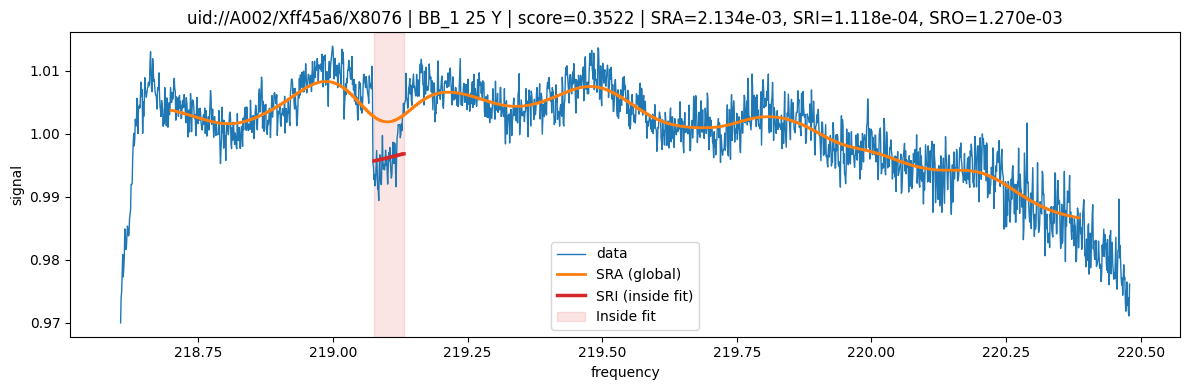

In [52]:
# Optional visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Raw signal
plt.plot(freq_array, x, color="C0", linewidth=1.0, label="data")

# Global fit (SRA)
plt.plot(freq_array, out["pred_all"], color="C1", linewidth=2.0, label="SRA (global)")

# Inside-only fit
inside = out["inside_idxs"]
plt.plot(
    freq_array[inside],
    out["pred_in"][inside],
    color="C3",
    linewidth=2.5,
    label="SRI (inside fit)",
)

# # Optional outside-only fit (SRO)
# if out.get("pred_out") is not None:
#     outside = out["outside_idxs"]
#     plt.plot(
#         y[outside],
#         out["pred_out"][outside],
#         color="C2",
#         linewidth=1.5,
#         linestyle="--",
#         label="SRO (outside fit)",
#     )

# Shade inside window
if inside.size:
    a, b = int(inside[0]), int(inside[-1])
    plt.axvspan(freq_array[a], freq_array[b], color="C3", alpha=0.12, label="Inside fit")

plt.title(
    f"{row.eb_uid} | {row.baseband_name} {row.spw_name_ms} {row.pol_id} | score={out['score']:.4f} | "
    f"SRA={out['sra']:.3e}, SRI={out['sri']:.3e}, SRO={out['sro']:.3e}"
)
plt.xlabel("frequency")
plt.ylabel("signal")
plt.legend(loc="best")
plt.tight_layout()
plt.show()



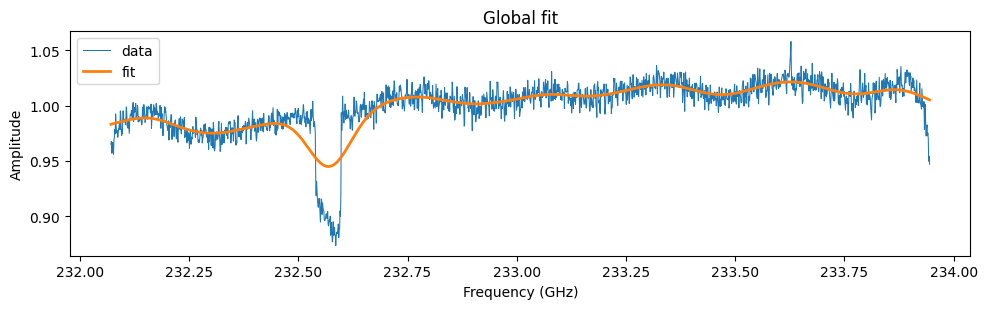

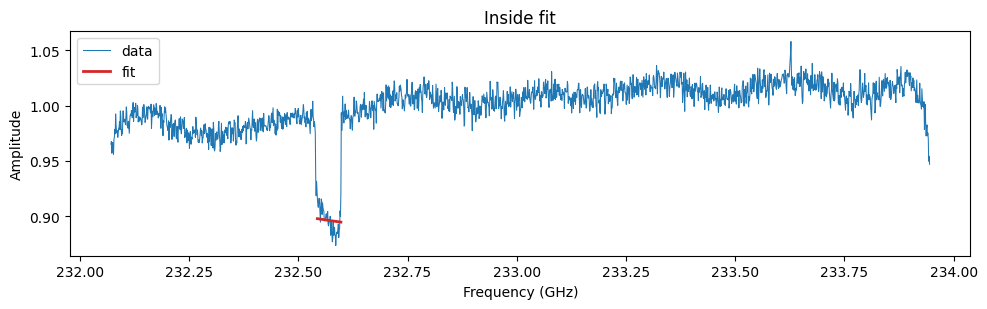

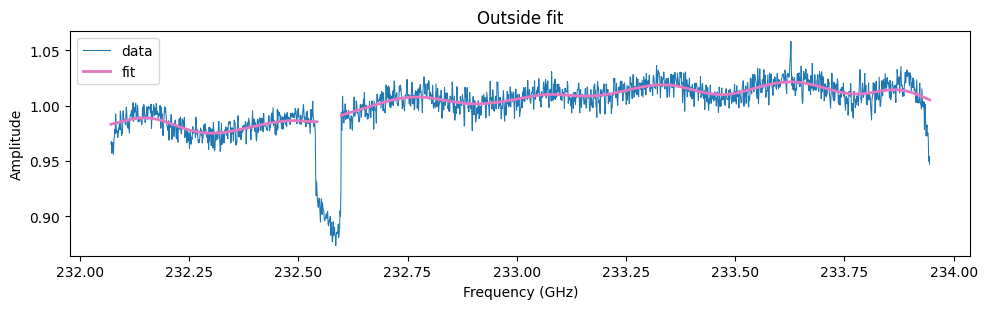

In [26]:
import matplotlib.pyplot as plt
import numpy as np

inside  = out["inside_idxs"]
outside = out["outside_idxs"]
full    = np.arange(len(x))

def scatter_with_gaps(ax, freq, signal, idxs, **kwargs):
    """Plot only the points at idxs, breaking the line at non-contiguous gaps."""
    # Build a full-length NaN array and fill only the selected indices
    y_plot = np.full(len(signal), np.nan)
    y_plot[idxs] = signal[idxs]
    ax.plot(freq, y_plot, **kwargs)

sections = [
    ("Global fit",  full,    full,    out["pred_all"], "C1"),
    ("Inside fit",  full,    inside,  out["pred_in"],  "C3"),
    ("Outside fit", full,    outside, out["pred_out"], "C76"),
]

for title, data_idxs, fit_idxs, pred, fit_color in sections:
    fig, ax = plt.subplots(figsize=(10, 3.2))
    # data is always the full spectrum
    ax.plot(freq_array[data_idxs], x[data_idxs], lw=0.75, color="#1f77b4", label="data")
    # fit only where it's defined, with NaN gaps breaking the line
    scatter_with_gaps(ax, freq_array, pred, fit_idxs, lw=2.0, color=fit_color, label="fit")
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("Amplitude")
    ax.set_title(title)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## Alternative regressors (mean, polynomial, KRR)

The cells below score the same window using the `regressors` module, which mirrors the benchmark path in `benchmark_regressor_on_syth.py`. Each block:
1. Builds the global SRA with `regressors.build_regressor_sra`
2. Predicts on `inside` / `outside` index sets
3. Computes SRI, SRO and the normalized score
4. Plots the result

Note: `sro` is set to 0 here (score = 1 - sri/sra) because the benchmark path does not separate inside/outside SSE the same way the NWKR path does.

In [36]:
# Shared setup — re-derive inside/outside from the same ranges used above
n = x.size
inside  = make_inside_idxs(inside_ranges, n)
outside = complement_idxs(inside, n)

### Mean regressor

In [38]:
sra, ssr_all, pred_all, K_all, alpha_all, ssr_ps_all, mean_precompute = regressors.build_regressor_sra(
    x,
    family="mean",
    degree=1
)

In [39]:
pred_in_vals = regressors.predict_on_idxs_mean(
    x,
    inside
)

pred_in = np.full_like(x, np.nan, dtype=np.float64)
pred_in[inside] = pred_in_vals

resid_in = x[inside] - pred_in_vals
sri = float(np.sum(resid_in ** 2))


In [40]:
pred_out = None
sro = 0.0

if outside.size:
    pred_out_vals = regressors.predict_on_idxs_mean(
        x,
        outside
    )

    pred_out = np.full_like(x, np.nan, dtype=np.float64)
    pred_out[outside] = pred_out_vals

    resid_out = x[outside] - pred_out_vals
    sro = float(np.sum(resid_out ** 2))


In [41]:
eps = 1e-12
score = 1.0 - (sri / max(sra, eps))

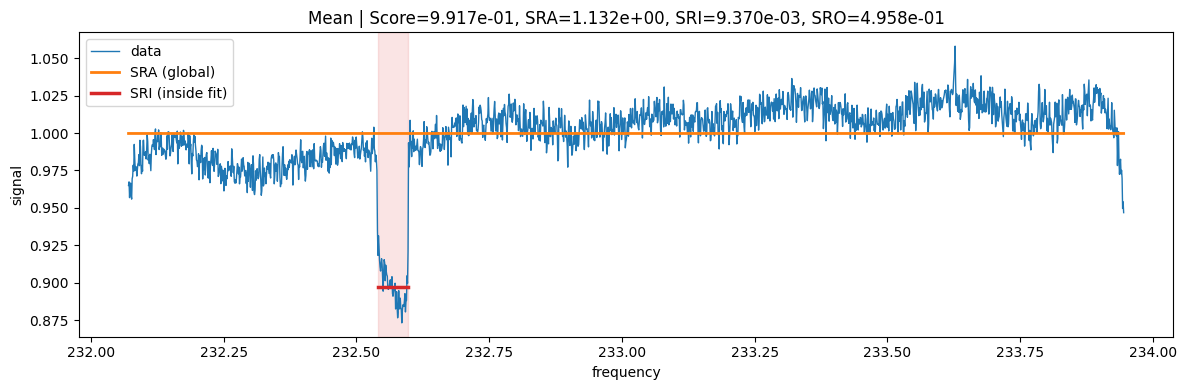

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Raw signal
plt.plot(freq_array, x, color="C0", linewidth=1.0, label="data")

# Global fit (SRA)
plt.plot(freq_array, pred_all, color="C1", linewidth=2.0, label="SRA (global)")

# Inside-only fit (SRI)
plt.plot(
    freq_array[inside],
    pred_in[inside],
    color="C3",
    linewidth=2.5,
    label="SRI (inside fit)",
)

# # Optional outside-only fit (SRO)
# if pred_out is not None:
#     plt.plot(
#         y[outside],
#         pred_out[outside],
#         color="C2",
#         linewidth=1.5,
#         linestyle="--",
#         label="SRO (outside fit)",
#     )

# Shade inside window
if inside.size:
    a, b = int(inside[0]), int(inside[-1])
    plt.axvspan(freq_array[a], freq_array[b], color="C3", alpha=0.12)

plt.title(
    f"Mean | "
    f"Score={score:.3e}, SRA={sra:.3e}, SRI={sri:.3e}, SRO={sro:.3e}"
)
plt.xlabel("frequency")
plt.ylabel("signal")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


### Polynomial regressor (degree 5)

In [47]:
sra, ssr_all, pred_all, K_all, alpha_all, ssr_ps_all, mean_precompute = regressors.build_regressor_sra(
    x,
    family="poly",
    degree=2
)

In [48]:
pred_in_vals = regressors.predict_on_idxs_poly(
    x,
    inside,
    degree=5
)

pred_in = np.full_like(x, np.nan, dtype=np.float64)
pred_in[inside] = pred_in_vals

resid_in = x[inside] - pred_in_vals
sri = float(np.sum(resid_in ** 2))


In [49]:
pred_out = None
sro = 0.0

if outside.size:
    pred_out_vals = regressors.predict_on_idxs_poly(
        x,
        outside,
        degree=5
    )

    pred_out = np.full_like(x, np.nan, dtype=np.float64)
    pred_out[outside] = pred_out_vals

    resid_out = x[outside] - pred_out_vals
    sro = float(np.sum(resid_out ** 2))


In [50]:
eps = 1e-12
score = 1.0 - (sri / max(sra, eps))

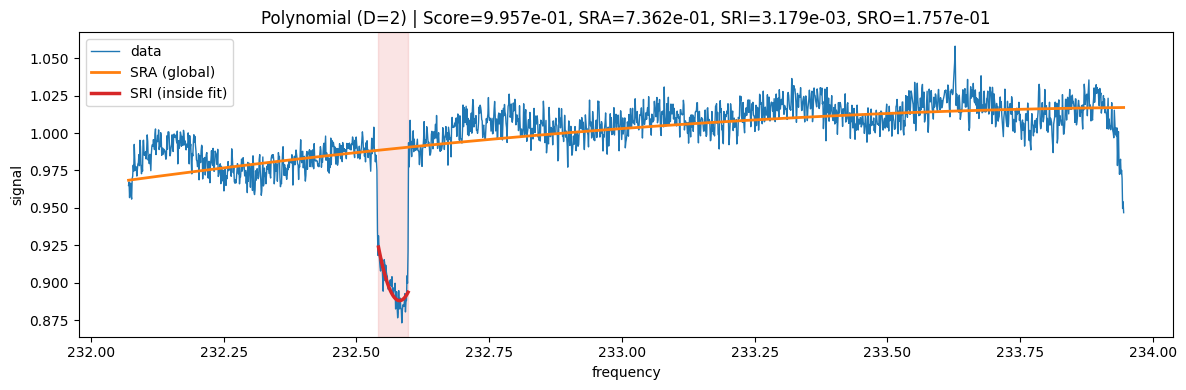

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Raw signal
plt.plot(freq_array, x, color="C0", linewidth=1.0, label="data")

# Global fit (SRA)
plt.plot(freq_array, pred_all, color="C1", linewidth=2.0, label="SRA (global)")

# Inside-only fit (SRI)
plt.plot(
    freq_array[inside],
    pred_in[inside],
    color="C3",
    linewidth=2.5,
    label="SRI (inside fit)",
)

# # Optional outside-only fit (SRO)
# if pred_out is not None:
#     plt.plot(
#         y[outside],
#         pred_out[outside],
#         color="C2",
#         linewidth=1.5,
#         linestyle="--",
#         label="SRO (outside fit)",
#     )

# Shade inside window
if inside.size:
    a, b = int(inside[0]), int(inside[-1])
    plt.axvspan(freq_array[a], freq_array[b], color="C3", alpha=0.12)

plt.title(
    f"Polynomial (D=2) | "
    f"Score={score:.3e}, SRA={sra:.3e}, SRI={sri:.3e}, SRO={sro:.3e}"
)
plt.xlabel("frequency")
plt.ylabel("signal")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


### KRR regressor (Gaussian kernel)

In [54]:
sra, ssr_all, pred_all, K_all, alpha_all, ssr_ps_all, mean_precompute = regressors.build_regressor_sra(
    x,
    family="krr",
)

In [55]:
pred_in_vals = regressors.predict_on_idxs_krr(
    x,
    inside,
    kernel="gaussian"
)

pred_in = np.full_like(x, np.nan, dtype=np.float64)
pred_in[inside] = pred_in_vals

resid_in = x[inside] - pred_in_vals
sri = float(np.sum(resid_in ** 2))


In [56]:
pred_out = None
sro = 0.0

if outside.size:
    pred_out_vals = regressors.predict_on_idxs_krr(
        x,
        outside,
        kernel="gaussian"
    )

    pred_out = np.full_like(x, np.nan, dtype=np.float64)
    pred_out[outside] = pred_out_vals

    resid_out = x[outside] - pred_out_vals
    sro = float(np.sum(resid_out ** 2))


In [57]:
eps = 1e-12
score = 1.0 - (sri / max(sra, eps))

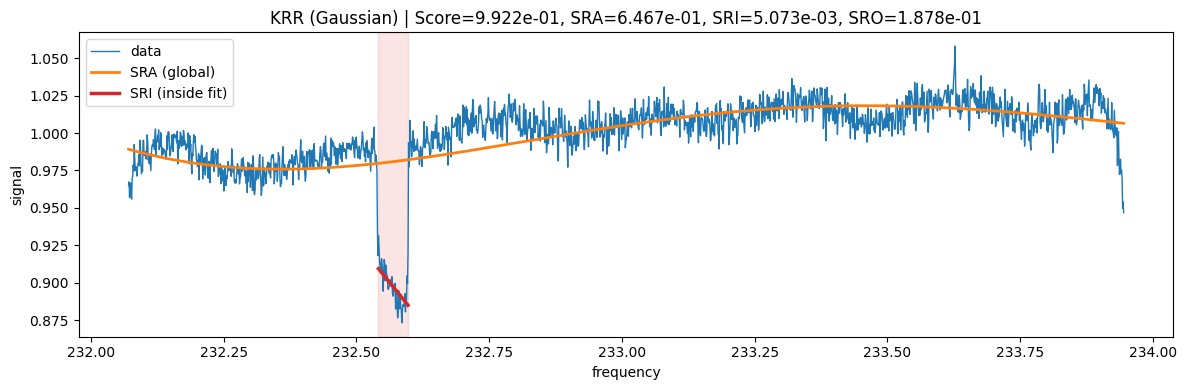

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Raw signal
plt.plot(freq_array, x, color="C0", linewidth=1.0, label="data")

# Global fit (SRA)
plt.plot(freq_array, pred_all, color="C1", linewidth=2.0, label="SRA (global)")

# Inside-only fit (SRI)
plt.plot(
    freq_array[inside],
    pred_in[inside],
    color="C3",
    linewidth=2.5,
    label="SRI (inside fit)",
)

# # Optional outside-only fit (SRO)
# if pred_out is not None:
#     plt.plot(
#         y[outside],
#         pred_out[outside],
#         color="C2",
#         linewidth=1.5,
#         linestyle="--",
#         label="SRO (outside fit)",
#     )

# Shade inside window
if inside.size:
    a, b = int(inside[0]), int(inside[-1])
    plt.axvspan(freq_array[a], freq_array[b], color="C3", alpha=0.12)

plt.title(
    f"KRR (Gaussian) | "
    f"Score={score:.3e}, SRA={sra:.3e}, SRI={sri:.3e}, SRO={sro:.3e}"
)
plt.xlabel("frequency")
plt.ylabel("signal")
plt.legend(loc="best")
plt.tight_layout()
plt.show()
